In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

Merged_df_PATH = Path("/home/bcrlab/igguest/porat_naama/data/processed/Corona_Mifkad2_merged.csv")
Corona_loc_df_PATH = Path("/home/bcrlab/igguest/porat_naama/data/processed/Corona_loc_processed.csv")

OUT_DIR = Path("/home/bcrlab/igguest/porat_naama/outputs/EDA")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Running list of (path, description) for every file this notebook saves
output_log = []

def log_output(path, description, description_he):
    output_log.append({"file_path": str(path), "contents": description, "contents_he": description_he})
    print("Saved:", path)

In [2]:
df_merged = pd.read_csv(Merged_df_PATH, dtype={"City_agas_code": str})
df_merged.set_index("City_agas_code", inplace=True)
df_merged.head()

/tmp/ipykernel_3591291/2884815790.py:1: DtypeWarning: Columns (32,34) have mixed types. Specify dtype option on import or set low_memory=False.
  df_merged = pd.read_csv(Merged_df_PATH, dtype={"City_agas_code": str})


,Unnamed: 0,town,date,accumulated_vaccination_first_dose,accumulated_vaccination_second_dose,accumulated_vaccination_third_dose,is_city_aggregate,tested_daily,infection_rate,recovery_ratio,...,household_family_idx,employment_idx,income_idx,housing_assets_idx,disability_idx,has_census,percent_vaccinated_first_dose,percent_vaccinated_second_dose,percent_vaccinated_third_dose,panic_index
City_agas_code,,,,,,,,,,,,,,,,,,,,,
1015_0,0,מבשרת ציון,2020-03-11,0,0,0,1,0.0,0.0,0.0,...,NaN,-0.761493,NaN,0.860699,1.06418,1,0.0,0.0,0.0,0.0
1015_0,1,מבשרת ציון,2020-03-12,0,0,0,1,0.0,0.0,0.0,...,NaN,-0.761493,NaN,0.860699,1.06418,1,0.0,0.0,0.0,0.0
1015_0,2,מבשרת ציון,2020-03-13,0,0,0,1,0.0,0.0,0.0,...,NaN,-0.761493,NaN,0.860699,1.06418,1,0.0,0.0,0.0,0.0
1015_0,3,מבשרת ציון,2020-03-14,0,0,0,1,0.0,0.0,0.0,...,NaN,-0.761493,NaN,0.860699,1.06418,1,0.0,0.0,0.0,0.0
1015_0,4,מבשרת ציון,2020-03-15,0,0,0,1,0.0,0.0,0.0,...,NaN,-0.761493,NaN,0.860699,1.06418,1,0.0,0.0,0.0,0.0


In [3]:
df_loc_corona = pd.read_csv(Corona_loc_df_PATH, dtype={"City_agas_code": str})
df_loc_corona.set_index("City_agas_code", inplace=True)
df_loc_corona.head()

,Unnamed: 0,town,date,accumulated_vaccination_first_dose,accumulated_vaccination_second_dose,accumulated_vaccination_third_dose,is_city_aggregate,tested_daily,infection_rate,recovery_ratio,...,infection_rate_window_days,is_lockdown,infection_rate_lag1,infection_rate_lag2,infection_rate_lag3,infection_rate_lag7,infection_rate_lag14,infection_rate_roll7,infection_rate_roll14,infection_rate_roll28
City_agas_code,,,,,,,,,,,,,,,,,,,,,
1015_0,0,מבשרת ציון,2020-03-11,0,0,0,1,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1015_0,1,מבשרת ציון,2020-03-12,0,0,0,1,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1015_0,2,מבשרת ציון,2020-03-13,0,0,0,1,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1015_0,3,מבשרת ציון,2020-03-14,0,0,0,1,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1015_0,4,מבשרת ציון,2020-03-15,0,0,0,1,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
with pd.option_context('display.max_rows', None):
    display(
        df_merged.loc[
            (pd.to_datetime(df_merged['date']).dt.date == pd.Timestamp('2022-03-16').date())
            & (df_merged.index.isin(['5000_0', '5000_114']))
        ].T
    )

City_agas_code,5000_0,5000_114
Unnamed: 0,778293,780641
town,תל אביב-יפו,תל אביב-יפו
date,2022-03-16,2022-03-16
accumulated_vaccination_first_dose,318829,6683
accumulated_vaccination_second_dose,304937,6481
accumulated_vaccination_third_dose,247409,5369
is_city_aggregate,1,0
tested_daily,3393.0,71.0
infection_rate,0.142352,0.140845
recovery_ratio,0.976615,0.975567


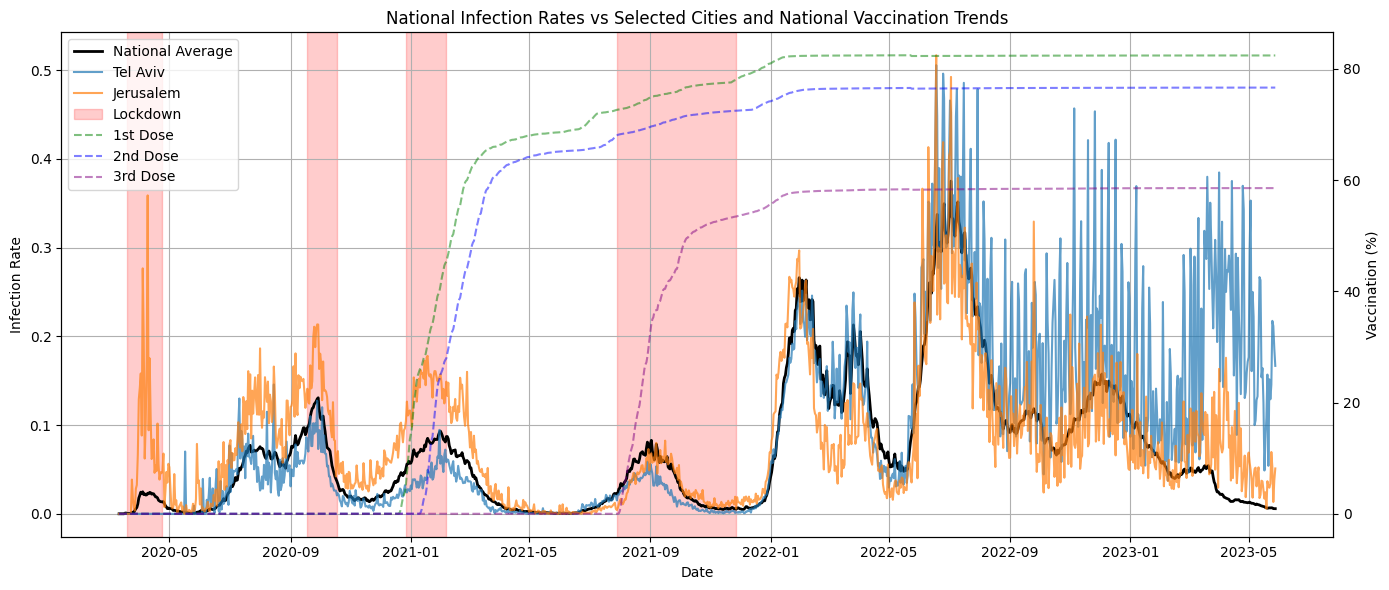

In [5]:
##general grph for infection rate and vaccination trends

# Make sure date is stored as datetime
df_merged['date'] = pd.to_datetime(df_merged['date'])


# National trend
national_trend = df_merged.groupby('date')['infection_rate'].mean()
vac_1_national_trend = df_merged.groupby('date')['percent_vaccinated_first_dose'].mean()
vac_2_national_trend = df_merged.groupby('date')['percent_vaccinated_second_dose'].mean()
vac_3_national_trend = df_merged.groupby('date')['percent_vaccinated_third_dose'].mean()




# Selected cities
selected_cities = ['5000_0', '3000_0']  # Tel Aviv, Jerusalem
city_trends = {}

for city in selected_cities:
    city_data = df_merged[df_merged.index == city].copy()
    city_data = city_data.sort_values('date')
    city_trends[city] = city_data.set_index('date')['infection_rate']

# Lockdown periods
lockdown_periods = [('2020-03-19', '2020-04-24'),
                    ('2020-09-18', '2020-10-18'),
                    ('2020-12-27', '2021-02-06'),
                    ('2021-07-29', '2021-11-27')]
lockdown_periods = [(pd.to_datetime(start), pd.to_datetime(end)) for start, end in lockdown_periods]

# Plotting
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot national trend
ax1.plot(national_trend.index, national_trend.values, label='National Average', linewidth=2, color='black')

# Plot selected cities
for city, series in city_trends.items():
    label = 'Tel Aviv' if city == '5000_0' else 'Jerusalem' if city == '3000_0' else city
    ax1.plot(series.index, series.values, label=label, alpha=0.7)

# Lockdown shading
for start, end in lockdown_periods:
    ax1.axvspan(start, end, color='red', alpha=0.2, label='Lockdown')

# Secondary Y-axis for vaccination trends

ax2 = ax1.twinx()
ax2.plot(vac_1_national_trend.index, vac_1_national_trend.values, label='1st Dose', alpha=0.5, color='green', linestyle='--')
ax2.plot(vac_2_national_trend.index, vac_2_national_trend.values, label='2nd Dose', alpha=0.5, color='blue', linestyle='--')
ax2.plot(vac_3_national_trend.index, vac_3_national_trend.values, label='3rd Dose', alpha=0.5, color='purple', linestyle='--')
ax2.set_ylabel("Vaccination (%)")

# Combine legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
by_label = dict(zip(labels1 + labels2, handles1 + handles2))

ax1.set_title("National Infection Rates vs Selected Cities and National Vaccination Trends")
ax1.set_xlabel("Date")
ax1.set_ylabel("Infection Rate")
ax1.legend(by_label.values(), by_label.keys(), loc='upper left')
ax1.grid(True)
fig.tight_layout()
plt.show()


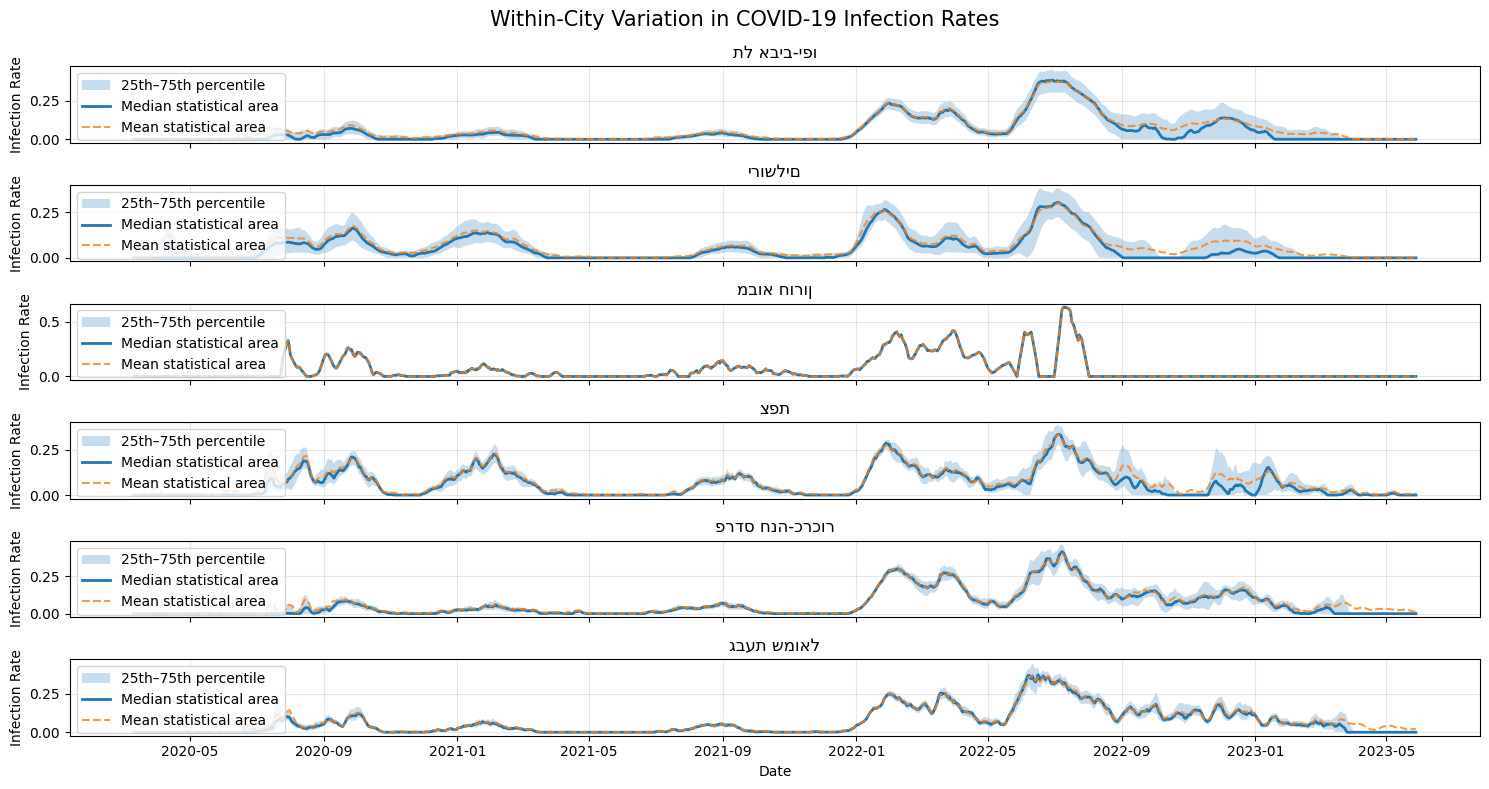

In [6]:
# ============================================================
# EDA: Within-city heterogeneity in infection rate over time
# Median across statistical areas + IQR (25th–75th percentile)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

CITY_COL = "town"   # <-- change if your city-name column has another name

CITIES = [
    "תל אביב-יפו",
    "ירושלים",
    "מבוא חורון",
    "צפת",
    "פרדס חנה-כרכור",
    "גבעת שמואל"
]

SMOOTHING_DAYS = 7


# ------------------------------------------------------------
# PREPARE DATA
# ------------------------------------------------------------

plot_df = df_loc_corona[
    df_loc_corona[CITY_COL].isin(CITIES)
].copy()

plot_df["date"] = pd.to_datetime(plot_df["date"])

# Keep only sensible infection-rate values
plot_df.loc[
    (plot_df["infection_rate"] < 0) |
    (plot_df["infection_rate"] > 1),
    "infection_rate"
] = np.nan


# ------------------------------------------------------------
# CALCULATE DAILY DISTRIBUTION ACROSS STATISTICAL AREAS
# ------------------------------------------------------------

city_daily = (
    plot_df
    .groupby([CITY_COL, "date"])["infection_rate"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        mean="mean",
        n_areas="count"
    )
    .reset_index()
)


# ------------------------------------------------------------
# OPTIONAL SMOOTHING
# ------------------------------------------------------------

city_daily = city_daily.sort_values([CITY_COL, "date"])

for col in ["median", "q25", "q75", "mean"]:
    city_daily[col + "_smooth"] = (
        city_daily
        .groupby(CITY_COL)[col]
        .transform(
            lambda x: x.rolling(
                SMOOTHING_DAYS,
                center=True,
                min_periods=1
            ).mean()
        )
    )


# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

fig, axes = plt.subplots(
    len(CITIES),
    1,
    figsize=(15, 8),
    sharex=True
)

if len(CITIES) == 1:
    axes = [axes]

for ax, city in zip(axes, CITIES):

    d = city_daily[
        city_daily[CITY_COL] == city
    ]

    # Interquartile range
    ax.fill_between(
        d["date"],
        d["q25_smooth"],
        d["q75_smooth"],
        alpha=0.25,
        label="25th–75th percentile"
    )

    # Median
    ax.plot(
        d["date"],
        d["median_smooth"],
        linewidth=2,
        label="Median statistical area"
    )

    # Mean
    ax.plot(
        d["date"],
        d["mean_smooth"],
        linestyle="--",
        linewidth=1.5,
        alpha=0.8,
        label="Mean statistical area"
    )

    ax.set_title(city)
    ax.set_ylabel("Infection Rate")

    ax.grid(
        alpha=0.3
    )

    ax.legend(
        loc="upper left"
    )


axes[-1].set_xlabel("Date")

fig.suptitle(
    "Within-City Variation in COVID-19 Infection Rates",
    fontsize=15
)

plt.tight_layout()
plt.show()

Number of statistical areas per locality:
town
תל אביב-יפו       112
ירושלים           148
מבוא חורון          1
צפת                 8
פרדס חנה-כרכור     10
גבעת שמואל          6
Name: City_agas_code, dtype: int64

Number of weekly observations:
town
תל אביב-יפו       18816
ירושלים           24864
מבוא חורון          168
צפת                1344
פרדס חנה-כרכור     1680
גבעת שמואל         1008
Name: infection_rate, dtype: int64

Common heatmap maximum: 0.406


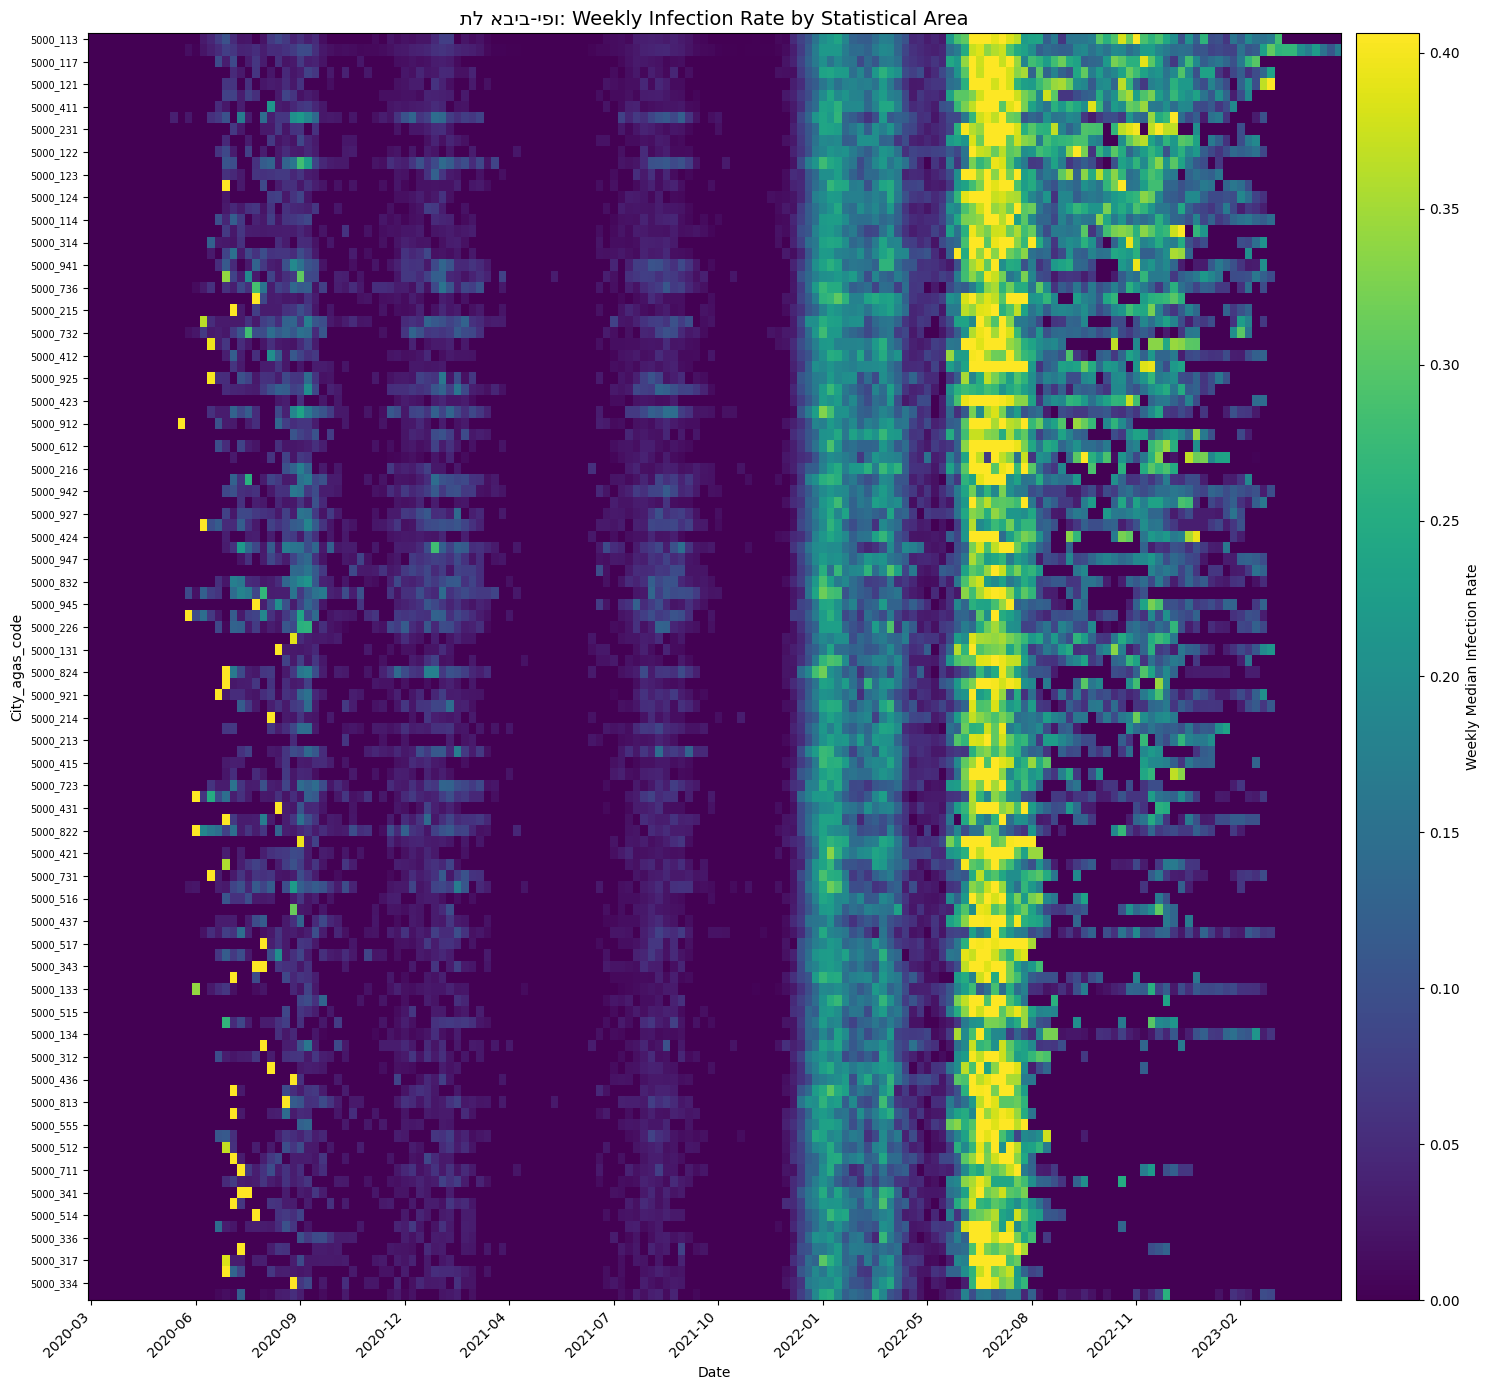

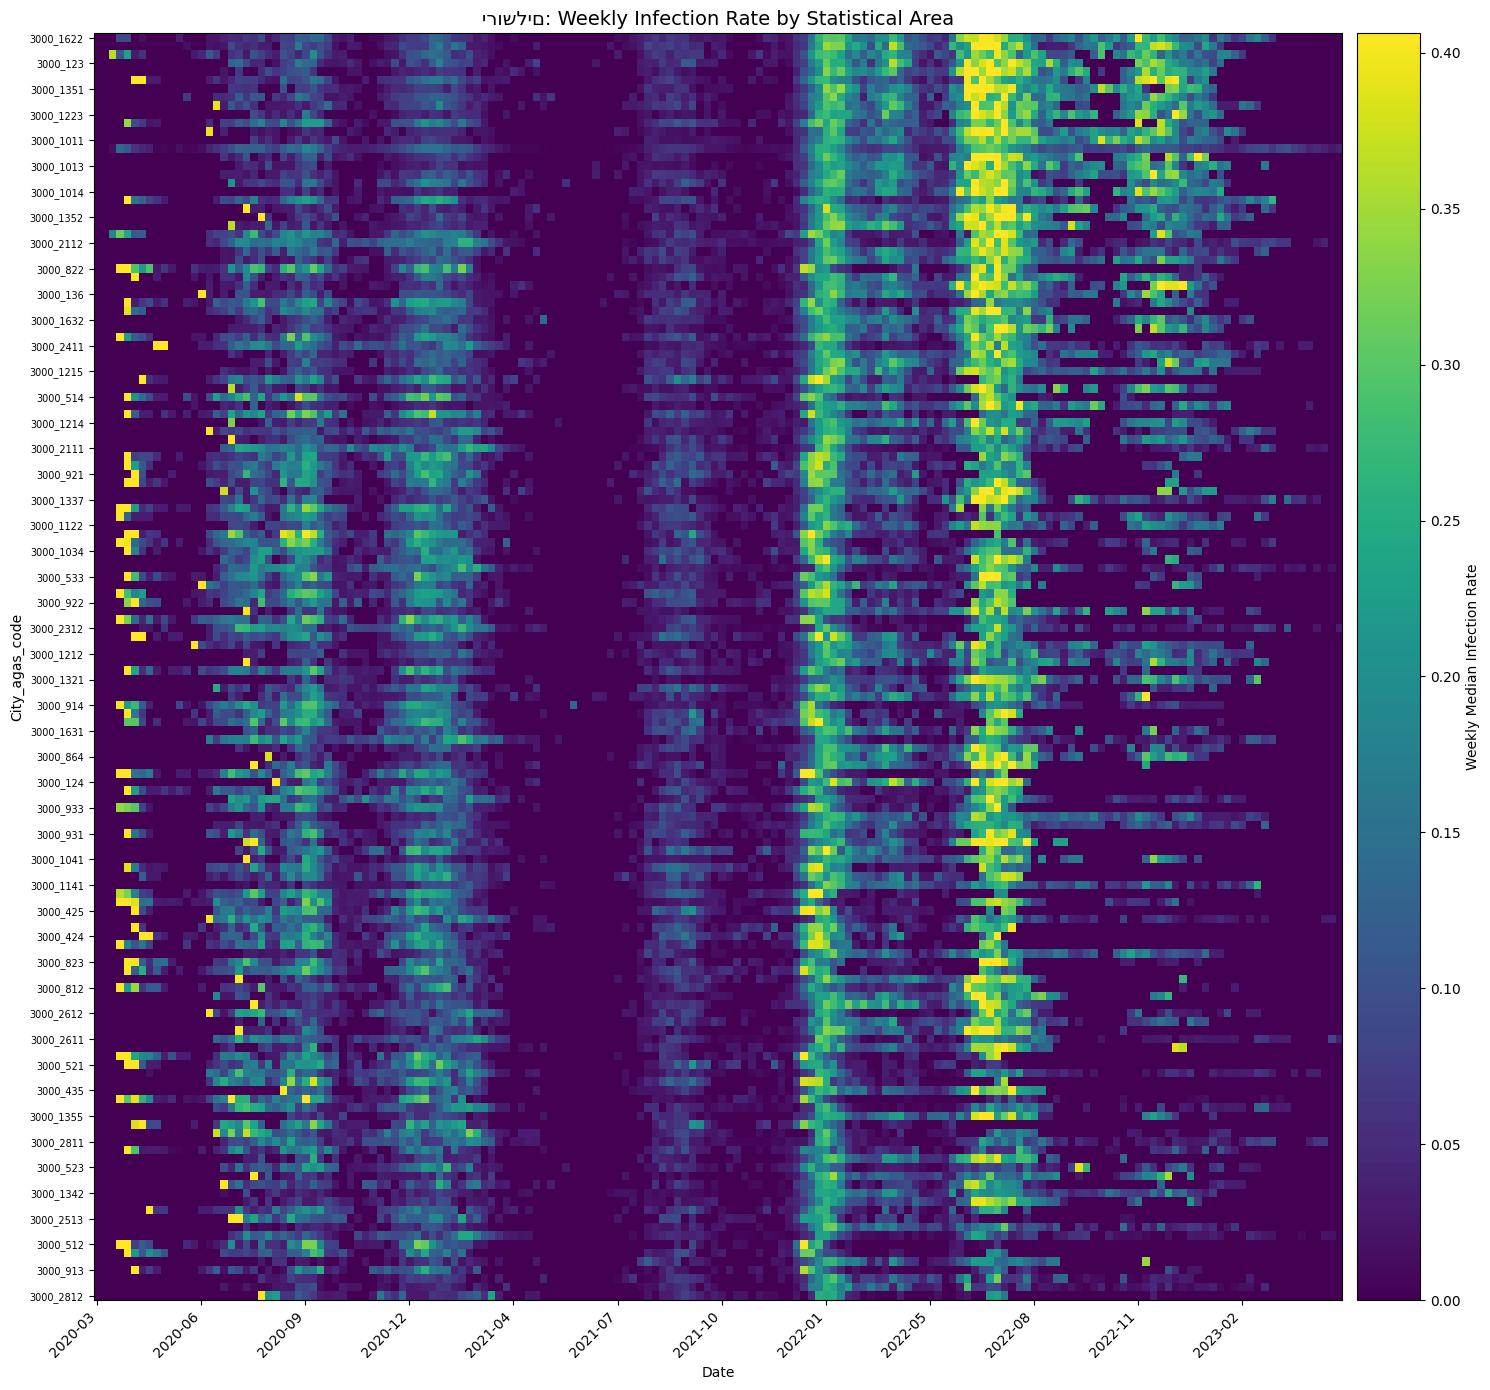

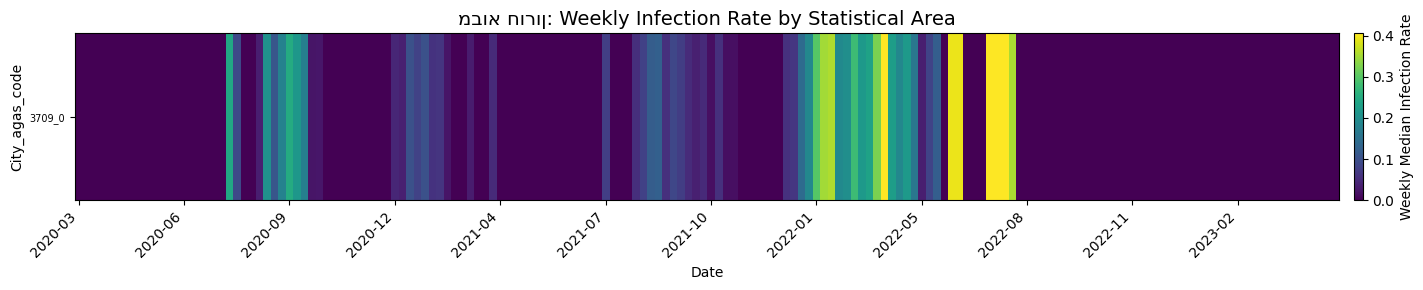

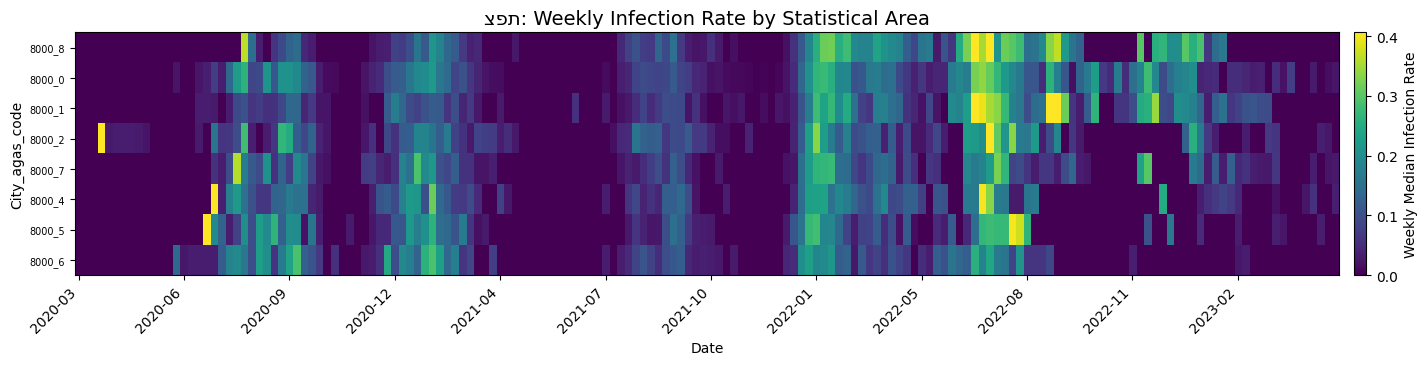

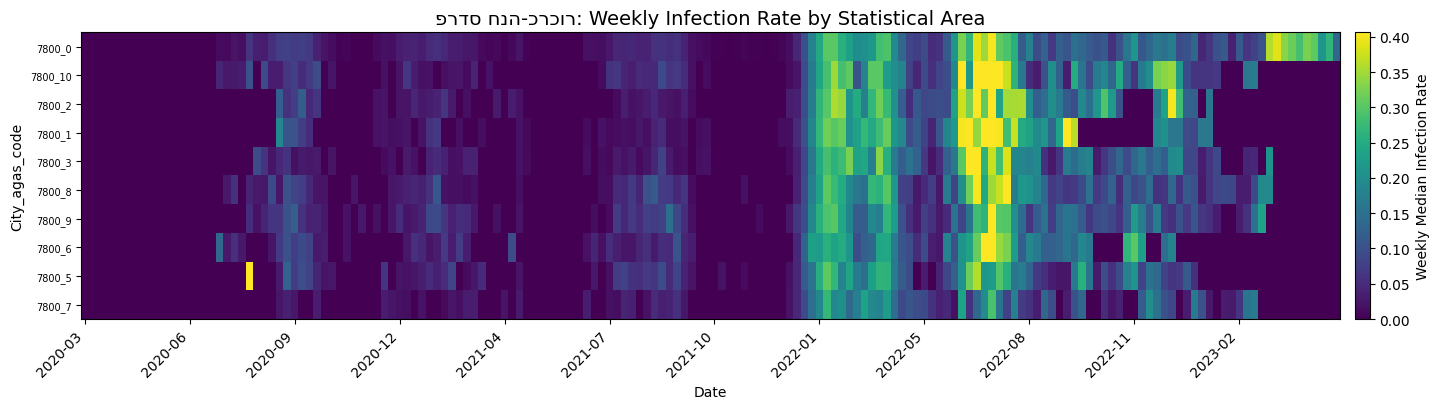

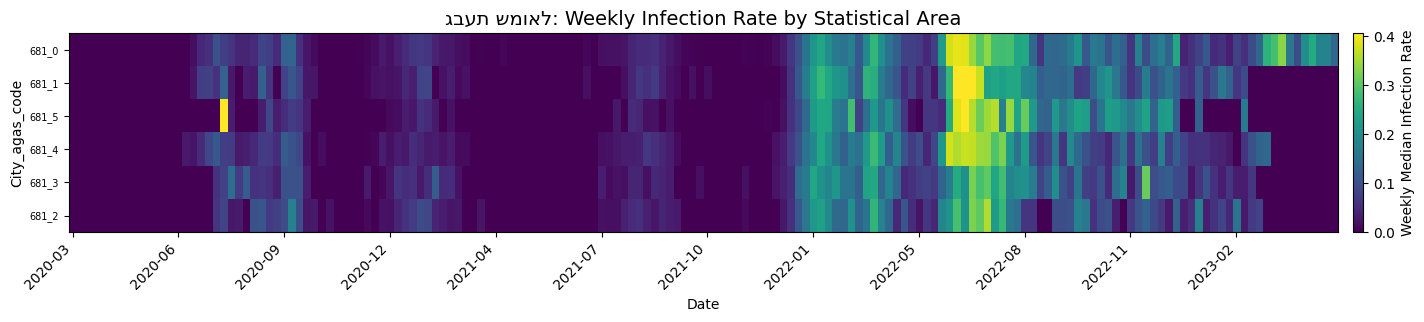

In [7]:
# ============================================================
# EDA: Weekly infection-rate heatmap by statistical area
# Uses the same cities and plot_df from the previous cell
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# PREPARE WEEKLY DATA
# ------------------------------------------------------------

heat_df = plot_df.copy()

heat_df["date"] = pd.to_datetime(
    heat_df["date"],
    errors="coerce"
)

heat_df["infection_rate"] = pd.to_numeric(
    heat_df["infection_rate"],
    errors="coerce"
)

# Remove impossible infection-rate values
heat_df.loc[
    (heat_df["infection_rate"] < 0)
    | (heat_df["infection_rate"] > 1),
    "infection_rate"
] = np.nan


# Assign each date to a week
heat_df["week"] = (
    heat_df["date"]
    .dt.to_period("W")
    .dt.start_time
)


# ------------------------------------------------------------
# WEEKLY MEDIAN INFECTION RATE
# FOR EACH STATISTICAL AREA
# ------------------------------------------------------------

weekly_area = (
    heat_df
    .groupby(
        ["town", "City_agas_code", "week"]
    )["infection_rate"]
    .median()
    .reset_index()
)


# ------------------------------------------------------------
# DIAGNOSTICS
# ------------------------------------------------------------

print("Number of statistical areas per locality:")
print(
    weekly_area
    .groupby("town")["City_agas_code"]
    .nunique()
    .reindex(CITIES)
)

print("\nNumber of weekly observations:")
print(
    weekly_area
    .groupby("town")["infection_rate"]
    .count()
    .reindex(CITIES)
)


# ------------------------------------------------------------
# USE ONE COMMON COLOR SCALE FOR ALL CITIES
# ------------------------------------------------------------

# 99th percentile prevents a few extreme observations
# from making the whole heatmap look dark.
VMAX = weekly_area["infection_rate"].quantile(0.99)

print(f"\nCommon heatmap maximum: {VMAX:.3f}")


# ------------------------------------------------------------
# HEATMAP FUNCTION
# ------------------------------------------------------------

def plot_city_heatmap(city):

    city_data = weekly_area[
        weekly_area["town"] == city
    ].copy()

    if city_data.empty:
        print(f"No data found for {city}")
        return

    # Rows = statistical areas
    # Columns = weeks
    matrix = city_data.pivot_table(
        index="City_agas_code",
        columns="week",
        values="infection_rate",
        aggfunc="median"
    )

    # Remove rows/columns containing only NaN
    matrix = matrix.dropna(
        axis=0,
        how="all"
    )

    matrix = matrix.dropna(
        axis=1,
        how="all"
    )

    if matrix.empty:
        print(f"No usable infection-rate data for {city}")
        return


    # --------------------------------------------------------
    # SORT AREAS
    # Highest average infection rate at the top
    # --------------------------------------------------------

    area_mean = matrix.mean(axis=1)

    area_order = (
        area_mean
        .sort_values(ascending=False)
        .index
    )

    matrix = matrix.loc[area_order]


    # --------------------------------------------------------
    # PLOT
    # --------------------------------------------------------

    fig_height = max(
        3,
        min(14, len(matrix) * 0.22 + 2)
    )

    fig, ax = plt.subplots(
        figsize=(16, fig_height)
    )

    im = ax.imshow(
        matrix.values,
        aspect="auto",
        interpolation="nearest",
        vmin=0,
        vmax=VMAX,
        cmap="viridis"
    )


    # --------------------------------------------------------
    # Y AXIS
    # --------------------------------------------------------

    # Avoid too many labels for large cities
    y_step = max(
        1,
        len(matrix.index) // 40
    )

    y_positions = np.arange(
        0,
        len(matrix.index),
        y_step
    )

    ax.set_yticks(y_positions)

    ax.set_yticklabels(
        matrix.index[y_positions],
        fontsize=7
    )


    # --------------------------------------------------------
    # X AXIS
    # --------------------------------------------------------

    n_weeks = len(matrix.columns)

    # Approximately 12 date labels
    x_step = max(
        1,
        n_weeks // 12
    )

    x_positions = np.arange(
        0,
        n_weeks,
        x_step
    )

    ax.set_xticks(x_positions)

    ax.set_xticklabels(
        [
            matrix.columns[i].strftime("%Y-%m")
            for i in x_positions
        ],
        rotation=45,
        ha="right"
    )


    # --------------------------------------------------------
    # LABELS
    # --------------------------------------------------------

    ax.set_title(
        f"{city}: Weekly Infection Rate by Statistical Area",
        fontsize=14
    )

    ax.set_xlabel("Date")
    ax.set_ylabel("City_agas_code")

    cbar = plt.colorbar(
        im,
        ax=ax,
        pad=0.01
    )

    cbar.set_label(
        "Weekly Median Infection Rate"
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# PLOT ALL SELECTED LOCALITIES
# ------------------------------------------------------------

for city in CITIES:
    plot_city_heatmap(city)

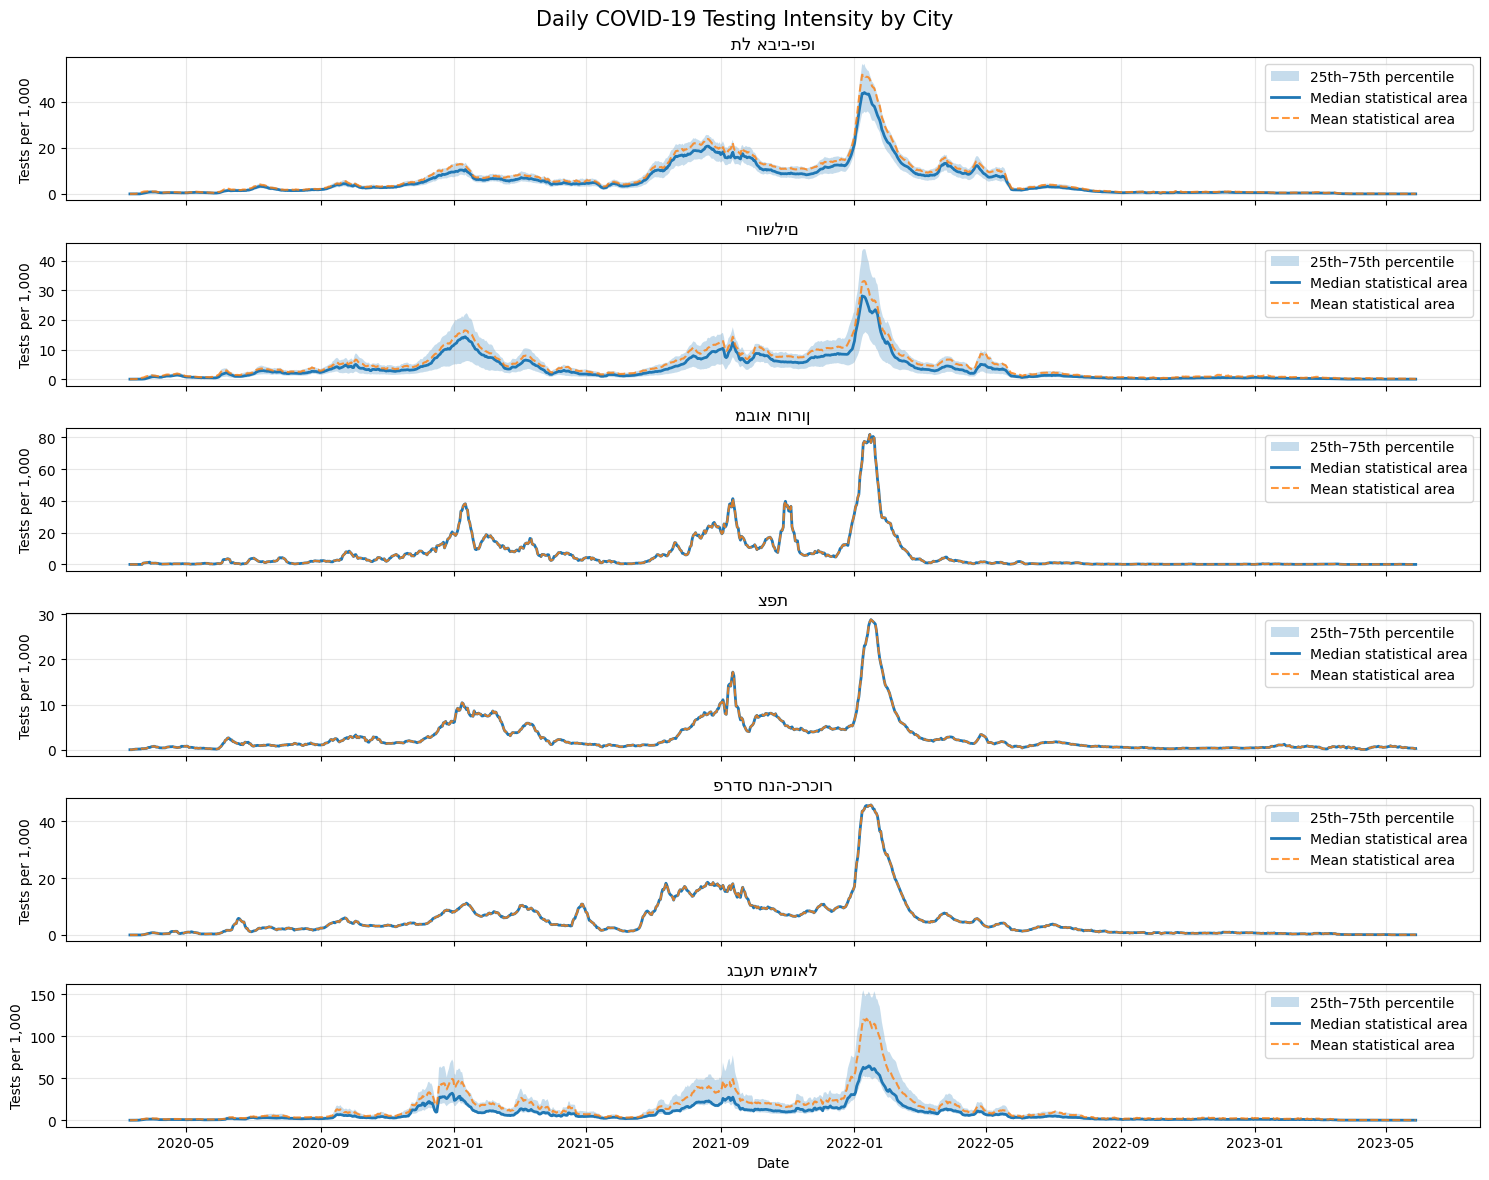

In [8]:
# ============================================================
# EDA: Panic index over time by city
# Median across statistical areas + IQR (25th–75th percentile)
#
# panic_index = daily tests per 1,000 residents
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

CITY_COL = "town"

CITIES = [
    "תל אביב-יפו",
    "ירושלים",
    "מבוא חורון",
    "צפת",
    "פרדס חנה-כרכור",
    "גבעת שמואל"
]

SMOOTHING_DAYS = 7


# ------------------------------------------------------------
# PREPARE DATA
# ------------------------------------------------------------

panic_df = df_merged[
    df_merged[CITY_COL].isin(CITIES)
].copy()

panic_df["date"] = pd.to_datetime(
    panic_df["date"],
    errors="coerce"
)

panic_df["panic_index"] = pd.to_numeric(
    panic_df["panic_index"],
    errors="coerce"
)


# Negative testing intensity is not meaningful
# and may result from retrospective corrections
panic_df.loc[
    panic_df["panic_index"] < 0,
    "panic_index"
] = np.nan


# ------------------------------------------------------------
# DAILY DISTRIBUTION ACROSS STATISTICAL AREAS
# ------------------------------------------------------------

panic_daily = (
    panic_df
    .groupby([CITY_COL, "date"])["panic_index"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        mean="mean",
        n_areas="count"
    )
    .reset_index()
)


# ------------------------------------------------------------
# 7-DAY SMOOTHING
# ------------------------------------------------------------

panic_daily = panic_daily.sort_values(
    [CITY_COL, "date"]
)

for col in ["median", "q25", "q75", "mean"]:

    panic_daily[f"{col}_smooth"] = (
        panic_daily
        .groupby(CITY_COL)[col]
        .transform(
            lambda x: x.rolling(
                window=SMOOTHING_DAYS,
                center=True,
                min_periods=1
            ).mean()
        )
    )


# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

fig, axes = plt.subplots(
    len(CITIES),
    1,
    figsize=(15, 12),
    sharex=True
)

if len(CITIES) == 1:
    axes = [axes]


for ax, city in zip(axes, CITIES):

    d = panic_daily[
        panic_daily[CITY_COL] == city
    ]

    # IQR: middle 50% of statistical areas
    ax.fill_between(
        d["date"],
        d["q25_smooth"],
        d["q75_smooth"],
        alpha=0.25,
        label="25th–75th percentile"
    )

    # Median statistical area
    ax.plot(
        d["date"],
        d["median_smooth"],
        linewidth=2,
        label="Median statistical area"
    )

    # Mean statistical area
    ax.plot(
        d["date"],
        d["mean_smooth"],
        linestyle="--",
        linewidth=1.5,
        alpha=0.8,
        label="Mean statistical area"
    )

    ax.set_title(city)

    ax.set_ylabel(
        "Tests per 1,000"
    )

    ax.grid(alpha=0.3)

    ax.legend(
        loc="upper right"
    )


axes[-1].set_xlabel("Date")

fig.suptitle(
    "Daily COVID-19 Testing Intensity by City",
    fontsize=15
)

plt.tight_layout()
plt.show()

lag_days           0      3      7      14     21     28
town                                                    
גבעת שמואל      0.140  0.151  0.166  0.185  0.188  0.185
ירושלים         0.518  0.527  0.537  0.542  0.536  0.527
מבוא חורון      0.548  0.556  0.560  0.545  0.519  0.514
פרדס חנה-כרכור  0.193  0.197  0.201  0.206  0.204  0.204
צפת             0.441  0.447  0.447  0.435  0.407  0.378
תל אביב-יפו     0.246  0.257  0.270  0.286  0.294  0.293


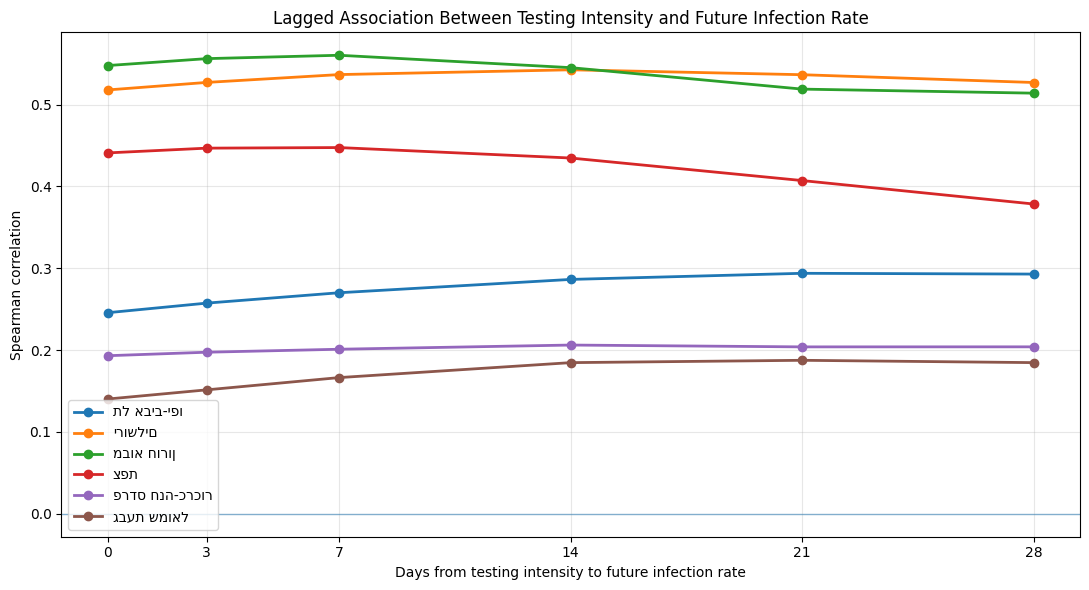

In [9]:
# ============================================================
# EDA: Does testing intensity precede infection rate?
# Spearman correlation between panic_index(t)
# and infection_rate(t + lag)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

CITIES_LAG = [
    "תל אביב-יפו",
    "ירושלים",
    "מבוא חורון",
    "צפת",
    "פרדס חנה-כרכור",
    "גבעת שמואל"
]

LAGS = [0, 3, 7, 14, 21, 28]

SMOOTHING_DAYS = 7


# ------------------------------------------------------------
# PREPARE DATA
# ------------------------------------------------------------

lag_df = df_merged[
    df_merged["town"].isin(CITIES_LAG)
].copy()

lag_df["date"] = pd.to_datetime(
    lag_df["date"],
    errors="coerce"
)

lag_df["infection_rate"] = pd.to_numeric(
    lag_df["infection_rate"],
    errors="coerce"
)

lag_df["panic_index"] = pd.to_numeric(
    lag_df["panic_index"],
    errors="coerce"
)

# Remove invalid values
lag_df.loc[
    (lag_df["infection_rate"] < 0)
    | (lag_df["infection_rate"] > 1),
    "infection_rate"
] = np.nan

lag_df.loc[
    lag_df["panic_index"] < 0,
    "panic_index"
] = np.nan


# ------------------------------------------------------------
# ONE DAILY VALUE PER CITY
# Use median across statistical areas
# ------------------------------------------------------------

city_daily = (
    lag_df
    .groupby(["town", "date"])
    .agg(
        infection_rate=("infection_rate", "median"),
        panic_index=("panic_index", "median")
    )
    .reset_index()
    .sort_values(["town", "date"])
)


# ------------------------------------------------------------
# 7-DAY SMOOTHING
# ------------------------------------------------------------

for col in ["infection_rate", "panic_index"]:

    city_daily[f"{col}_smooth"] = (
        city_daily
        .groupby("town")[col]
        .transform(
            lambda x: x.rolling(
                SMOOTHING_DAYS,
                center=True,
                min_periods=1
            ).mean()
        )
    )


# ------------------------------------------------------------
# CALCULATE LAGGED SPEARMAN CORRELATIONS
#
# Question:
# Does panic_index today correlate with
# infection_rate X days in the future?
# ------------------------------------------------------------

results = []

for city in CITIES_LAG:

    d = city_daily[
        city_daily["town"] == city
    ][
        [
            "date",
            "panic_index_smooth",
            "infection_rate_smooth"
        ]
    ].copy()

    for lag in LAGS:

        # Future infection-rate table
        future = d[
            ["date", "infection_rate_smooth"]
        ].copy()

        # Shift the DATE backward so infection at t+lag
        # lines up with panic at time t
        future["date"] = (
            future["date"]
            - pd.Timedelta(days=lag)
        )

        future = future.rename(
            columns={
                "infection_rate_smooth":
                "future_infection_rate"
            }
        )

        merged_lag = d[
            ["date", "panic_index_smooth"]
        ].merge(
            future,
            on="date",
            how="inner"
        )

        merged_lag = merged_lag.dropna()

        if len(merged_lag) >= 10:

            rho = merged_lag[
                [
                    "panic_index_smooth",
                    "future_infection_rate"
                ]
            ].corr(
                method="spearman"
            ).iloc[0, 1]

        else:
            rho = np.nan

        results.append({
            "town": city,
            "lag_days": lag,
            "spearman_rho": rho,
            "n": len(merged_lag)
        })


lag_results = pd.DataFrame(results)


# ------------------------------------------------------------
# PRINT RESULTS
# ------------------------------------------------------------

print(
    lag_results
    .pivot(
        index="town",
        columns="lag_days",
        values="spearman_rho"
    )
    .round(3)
)


# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 6)
)

for city in CITIES_LAG:

    d = lag_results[
        lag_results["town"] == city
    ]

    ax.plot(
        d["lag_days"],
        d["spearman_rho"],
        marker="o",
        linewidth=2,
        label=city
    )


ax.axhline(
    0,
    linewidth=1,
    alpha=0.5
)

ax.set_xlabel(
    "Days from testing intensity to future infection rate"
)

ax.set_ylabel(
    "Spearman correlation"
)

ax.set_title(
    "Lagged Association Between Testing Intensity and Future Infection Rate"
)

ax.set_xticks(LAGS)

ax.grid(alpha=0.3)

ax.legend()

plt.tight_layout()
plt.show()

Median autocorrelation across statistical areas:

lag_days        1      3      7      14     21     28
town                                                 
תל אביב-יפו  0.884  0.795  0.727  0.650  0.600  0.537
ירושלים      0.890  0.803  0.722  0.624  0.550  0.464
מבוא חורון   0.912  0.824  0.723  0.587  0.532  0.486
צפת          0.906  0.805  0.710  0.590  0.527  0.457
קשת יהונתן     NaN    NaN    NaN    NaN    NaN    NaN


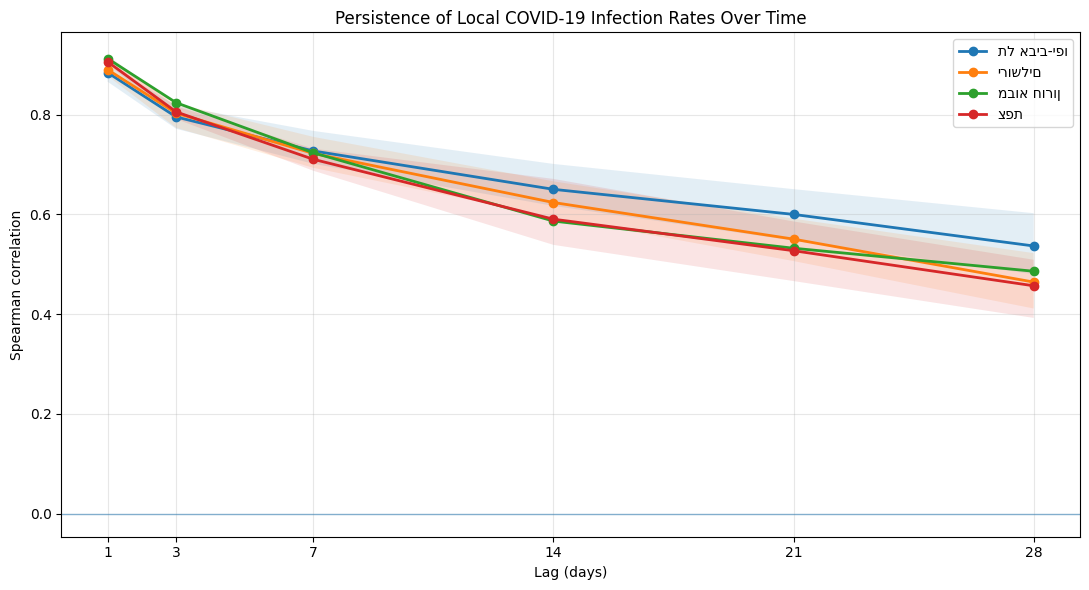

In [10]:
# ============================================================
# EDA: Temporal persistence of infection rate
# Spearman correlation between infection_rate(t)
# and infection_rate(t + lag)
#
# Calculated separately for every statistical area,
# then summarized by city.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

CITIES_EDA = [
    "תל אביב-יפו",
    "ירושלים",
    "מבוא חורון",
    "צפת",
    "קשת יהונתן"
]

LAGS = [1, 3, 7, 14, 21, 28]

MIN_PAIRS = 30

# ============================================================
# PREPARE DATA
# City_agas_code is stored in the index
# ============================================================

auto_df = df_loc_corona.reset_index().copy()

auto_df = auto_df[
    auto_df["town"].isin(CITIES_EDA)
][
    [
        "town",
        "City_agas_code",
        "date",
        "infection_rate"
    ]
].copy()

auto_df["date"] = pd.to_datetime(
    auto_df["date"],
    errors="coerce"
)

auto_df["infection_rate"] = pd.to_numeric(
    auto_df["infection_rate"],
    errors="coerce"
)

# Remove invalid values
auto_df.loc[
    (auto_df["infection_rate"] < 0)
    | (auto_df["infection_rate"] > 1),
    "infection_rate"
] = np.nan

auto_df = auto_df.dropna(
    subset=[
        "City_agas_code",
        "date",
        "infection_rate"
    ]
)

auto_df = auto_df.sort_values(
    ["City_agas_code", "date"]
)


# ------------------------------------------------------------
# CALCULATE CORRELATION FOR EACH STATISTICAL AREA
# ------------------------------------------------------------

results = []

for (town, area), d in auto_df.groupby(
    ["town", "City_agas_code"]
):

    d = (
        d[["date", "infection_rate"]]
        .drop_duplicates("date")
        .sort_values("date")
    )

    for lag in LAGS:

        # infection rate at time t
        current = d.rename(
            columns={
                "infection_rate": "infection_t"
            }
        )

        # infection rate at time t + lag
        future = d.copy()

        future["date"] = (
            future["date"]
            - pd.Timedelta(days=lag)
        )

        future = future.rename(
            columns={
                "infection_rate":
                "infection_future"
            }
        )

        paired = current.merge(
            future,
            on="date",
            how="inner"
        )

        paired = paired.dropna(
            subset=[
                "infection_t",
                "infection_future"
            ]
        )

        if (
            len(paired) >= MIN_PAIRS
            and paired["infection_t"].nunique() > 1
            and paired["infection_future"].nunique() > 1
        ):

            rho = paired[
                [
                    "infection_t",
                    "infection_future"
                ]
            ].corr(
                method="spearman"
            ).iloc[0, 1]

        else:
            rho = np.nan

        results.append({
            "town": town,
            "City_agas_code": area,
            "lag_days": lag,
            "spearman_rho": rho,
            "n_pairs": len(paired)
        })


autocorr_area = pd.DataFrame(results)


# ------------------------------------------------------------
# SUMMARIZE ACROSS STATISTICAL AREAS WITHIN EACH CITY
# ------------------------------------------------------------

autocorr_city = (
    autocorr_area
    .groupby(["town", "lag_days"])["spearman_rho"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        mean="mean",
        n_areas="count"
    )
    .reset_index()
)


# ------------------------------------------------------------
# PRINT TABLE
# ------------------------------------------------------------

print("Median autocorrelation across statistical areas:\n")

print(
    autocorr_city
    .pivot(
        index="town",
        columns="lag_days",
        values="median"
    )
    .reindex(CITIES_EDA)
    .round(3)
)


# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 6)
)

for city in CITIES_EDA:

    d = autocorr_city[
        autocorr_city["town"] == city
    ]

    if d.empty:
        continue

    ax.plot(
        d["lag_days"],
        d["median"],
        marker="o",
        linewidth=2,
        label=city
    )

    # IQR across statistical areas
    ax.fill_between(
        d["lag_days"],
        d["q25"],
        d["q75"],
        alpha=0.12
    )


ax.axhline(
    0,
    linewidth=1,
    alpha=0.5
)

ax.set_xlabel(
    "Lag (days)"
)

ax.set_ylabel(
    "Spearman correlation"
)

ax.set_title(
    "Persistence of Local COVID-19 Infection Rates Over Time"
)

ax.set_xticks(LAGS)

ax.grid(
    alpha=0.3
)

ax.legend()

plt.tight_layout()
plt.show()

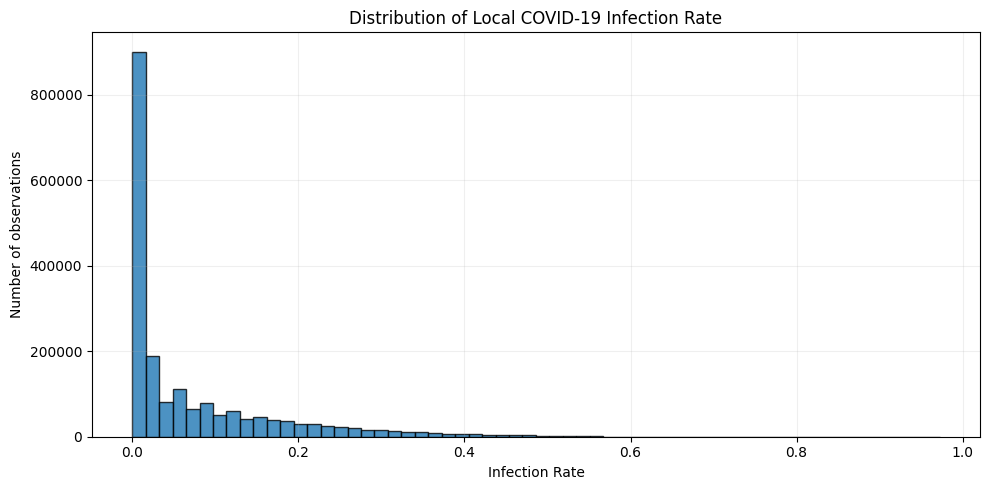

INFECTION RATE SUMMARY
----------------------
count    1.942906e+06
mean     7.056047e-02
std      1.027470e-01
min      0.000000e+00
25%      0.000000e+00
50%      2.439024e-02
75%      1.052632e-01
90%      2.222222e-01
95%      2.941176e-01
99%      4.358974e-01
max      9.722222e-01
Name: infection_rate, dtype: float64

Exactly zero: 859,313 (44.23%)
Missing: 0 (0.00%)


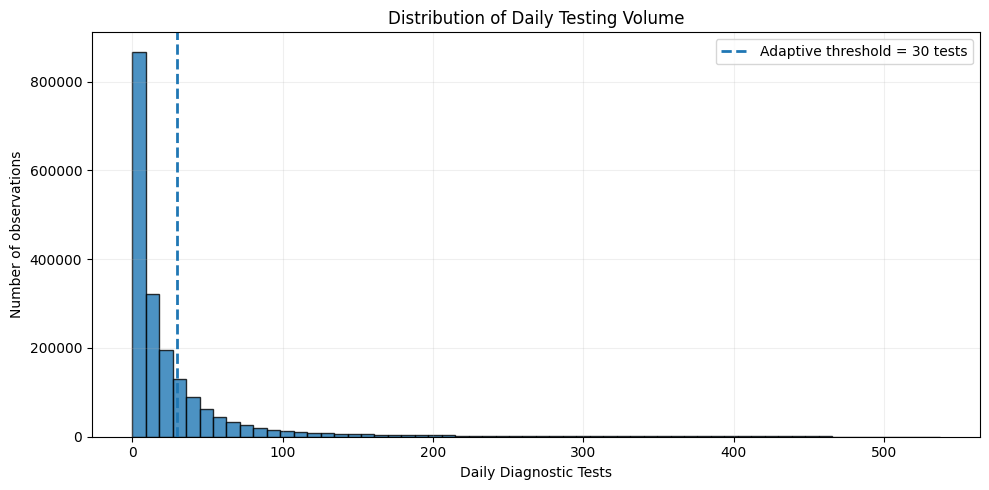


INFECTION RATE BY TESTING VOLUME
--------------------------------
  testing_bin  n_rows  median_infection_rate  mean_infection_rate  \
0         0–4  628722                 0.0000               0.0514   
1         5–9  284760                 0.0312               0.0855   
2       10–19  326743                 0.0299               0.0818   
3       20–29  193123                 0.0303               0.0733   
4       30–49  208565                 0.0294               0.0675   
5       50–99  165433                 0.0392               0.0770   
6     100–249   89105                 0.0654               0.0968   
7        250+   46455                 0.0581               0.0877   

   zero_fraction  
0         0.6481  
1         0.4252  
2         0.4009  
3         0.3517  
4         0.3822  
5         0.2395  
6         0.1135  
7         0.0525  


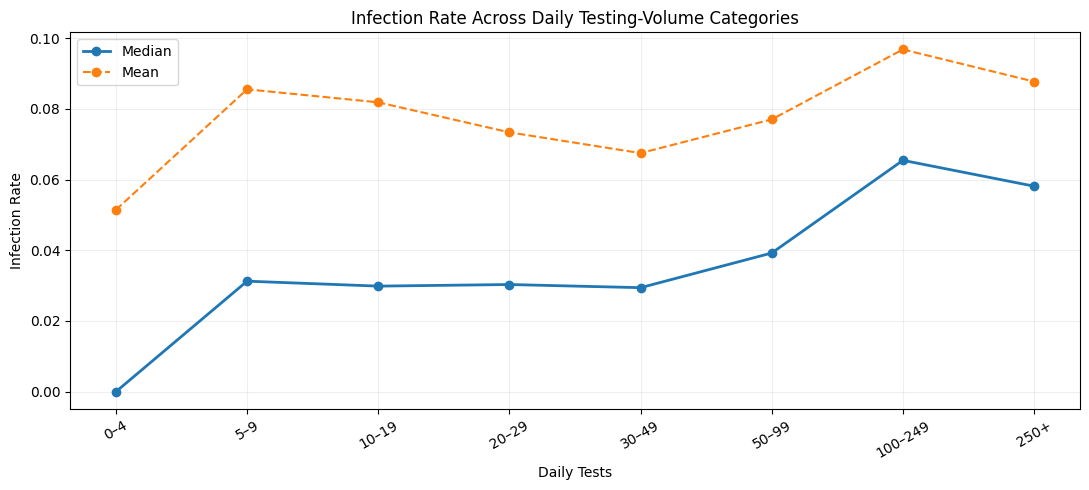

In [11]:
# ============================================================
# EDA: Target distribution + testing-volume diagnostics
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# PREPARE DATA
# ------------------------------------------------------------

eda_target = df_loc_corona.copy()

eda_target["infection_rate"] = pd.to_numeric(
    eda_target["infection_rate"],
    errors="coerce"
)

eda_target["tested_daily"] = pd.to_numeric(
    eda_target["tested_daily"],
    errors="coerce"
)

# Keep valid infection rates
eda_target.loc[
    (eda_target["infection_rate"] < 0)
    | (eda_target["infection_rate"] > 1),
    "infection_rate"
] = np.nan

# Negative daily tests are likely corrections / artifacts
eda_target.loc[
    eda_target["tested_daily"] < 0,
    "tested_daily"
] = np.nan


# ============================================================
# 1. DISTRIBUTION OF INFECTION RATE
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    eda_target["infection_rate"].dropna(),
    bins=60,
    edgecolor="black",
    alpha=0.8
)

ax.set_xlabel("Infection Rate")
ax.set_ylabel("Number of observations")

ax.set_title(
    "Distribution of Local COVID-19 Infection Rate"
)

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# PRINT BASIC TARGET STATISTICS
# ------------------------------------------------------------

valid_rate = eda_target["infection_rate"].dropna()

print("INFECTION RATE SUMMARY")
print("----------------------")

print(valid_rate.describe(
    percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
))

print(
    f"\nExactly zero: "
    f"{(valid_rate == 0).sum():,} "
    f"({(valid_rate == 0).mean()*100:.2f}%)"
)

print(
    f"Missing: "
    f"{eda_target['infection_rate'].isna().sum():,} "
    f"({eda_target['infection_rate'].isna().mean()*100:.2f}%)"
)


# ============================================================
# 2. DISTRIBUTION OF DAILY TESTING VOLUME
# ============================================================

# Use 99th percentile so extreme test days do not squash the plot
test_upper = eda_target["tested_daily"].quantile(0.99)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    eda_target.loc[
        eda_target["tested_daily"] <= test_upper,
        "tested_daily"
    ].dropna(),
    bins=60,
    edgecolor="black",
    alpha=0.8
)

ax.axvline(
    30,
    linestyle="--",
    linewidth=2,
    label="Adaptive threshold = 30 tests"
)

ax.set_xlabel("Daily Diagnostic Tests")
ax.set_ylabel("Number of observations")

ax.set_title(
    "Distribution of Daily Testing Volume"
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ============================================================
# 3. INFECTION RATE BY TESTING-VOLUME BIN
# ============================================================

test_bins = [
    0,
    5,
    10,
    20,
    30,
    50,
    100,
    250,
    np.inf
]

test_labels = [
    "0–4",
    "5–9",
    "10–19",
    "20–29",
    "30–49",
    "50–99",
    "100–249",
    "250+"
]

eda_target["testing_bin"] = pd.cut(
    eda_target["tested_daily"],
    bins=test_bins,
    labels=test_labels,
    right=False
)


testing_summary = (
    eda_target
    .groupby("testing_bin", observed=False)
    .agg(
        n_rows=("infection_rate", "size"),
        median_infection_rate=("infection_rate", "median"),
        mean_infection_rate=("infection_rate", "mean"),
        zero_fraction=(
            "infection_rate",
            lambda x: (x == 0).mean()
        )
    )
    .reset_index()
)

print("\nINFECTION RATE BY TESTING VOLUME")
print("--------------------------------")

print(
    testing_summary.round(4)
)


fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    testing_summary["testing_bin"].astype(str),
    testing_summary["median_infection_rate"],
    marker="o",
    linewidth=2,
    label="Median"
)

ax.plot(
    testing_summary["testing_bin"].astype(str),
    testing_summary["mean_infection_rate"],
    marker="o",
    linestyle="--",
    linewidth=1.5,
    label="Mean"
)

ax.set_xlabel("Daily Tests")
ax.set_ylabel("Infection Rate")

ax.set_title(
    "Infection Rate Across Daily Testing-Volume Categories"
)

ax.grid(alpha=0.2)
ax.legend()

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()